# Exploratory Data Analysis
## Tabular-to-Image Seminar — Dataset Profiling

For each of the 3 datasets we generate:
1. Class distribution (bar chart)
2. Feature distributions (histograms)
3. Correlation heatmap
4. Missing values report
5. Summary statistics table

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.preprocessing import preprocess_dataset

sns.set_theme(style='whitegrid', font_scale=1.1)
FIG_DIR = Path('..') / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete')

Setup complete


---
## 1. Breast Cancer Wisconsin

In [2]:
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
df_bc = pd.DataFrame(bc.data, columns=bc.feature_names)
df_bc['target'] = bc.target
df_bc['class'] = df_bc['target'].map({0: 'malignant', 1: 'benign'})

print(f'Shape: {df_bc.shape}')
print(f'Classes: {df_bc["class"].value_counts().to_dict()}')
print(f'Missing values: {df_bc.isnull().sum().sum()}')
df_bc.describe().round(3)

Shape: (569, 32)
Classes: {'benign': 357, 'malignant': 212}
Missing values: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


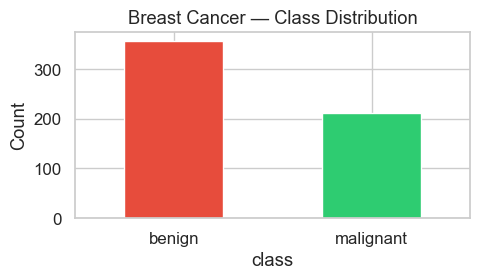

In [3]:
# Class distribution
fig, ax = plt.subplots(figsize=(5, 3))
df_bc['class'].value_counts().plot.bar(ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title('Breast Cancer — Class Distribution')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_breast_cancer_classes.png', dpi=150)
plt.show()

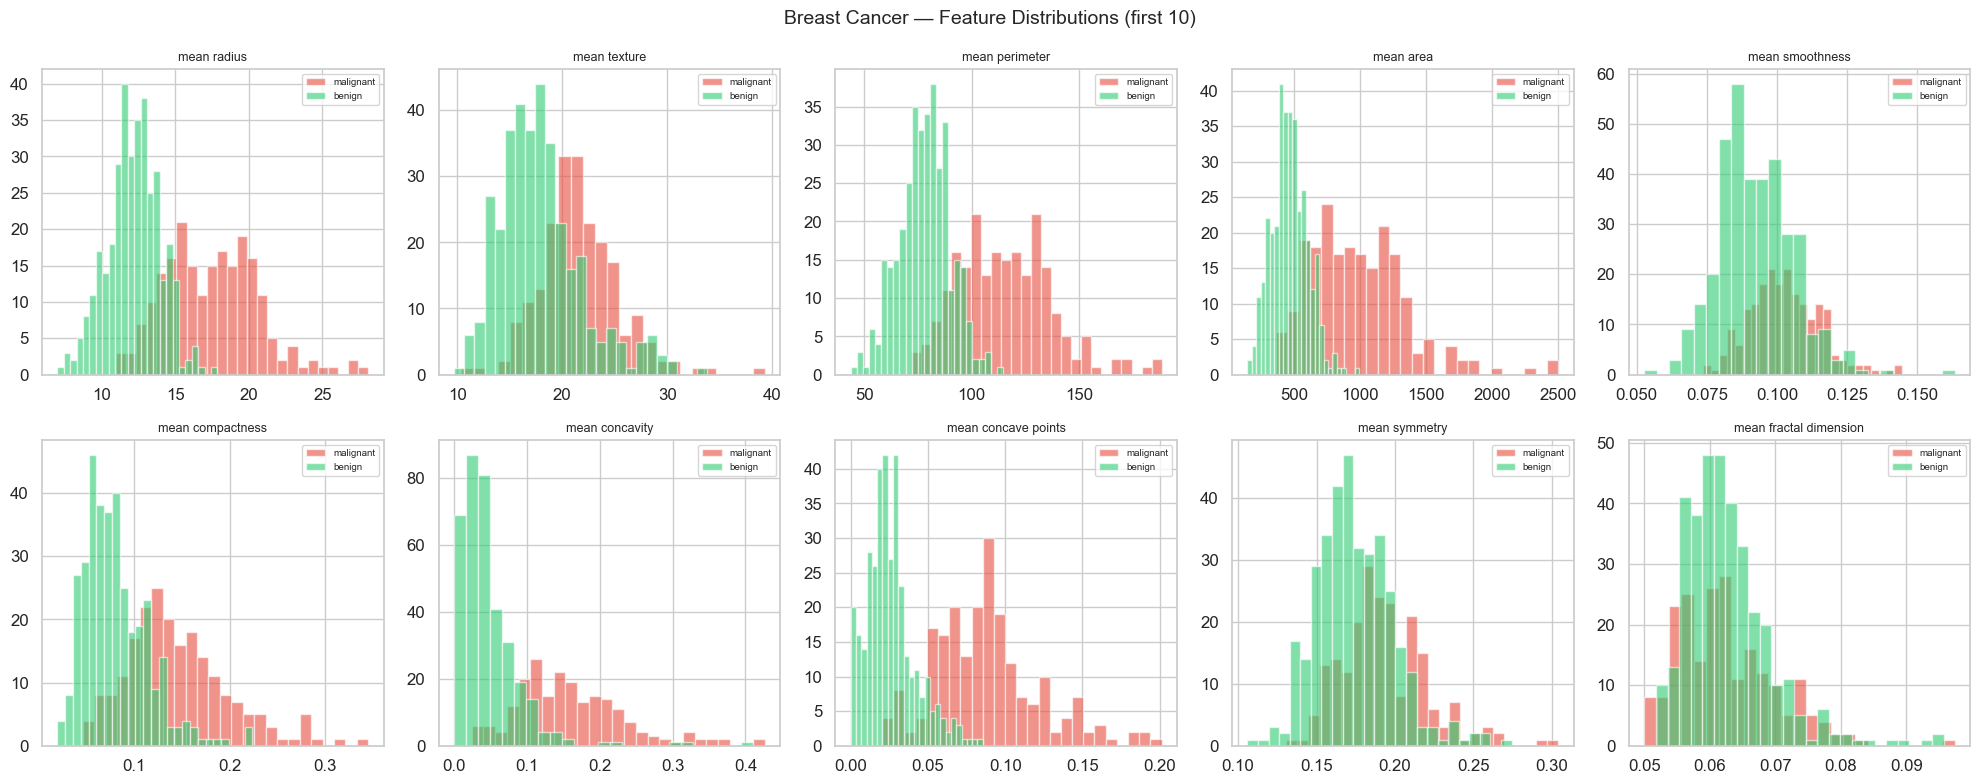

In [4]:
# Feature distributions (first 10 features)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(bc.feature_names[:10]):
    ax = axes[i // 5, i % 5]
    for cls, color in zip(['malignant', 'benign'], ['#e74c3c', '#2ecc71']):
        ax.hist(df_bc[df_bc['class'] == cls][col], bins=25, alpha=0.6, color=color, label=cls)
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)
fig.suptitle('Breast Cancer — Feature Distributions (first 10)', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_breast_cancer_features.png', dpi=150)
plt.show()

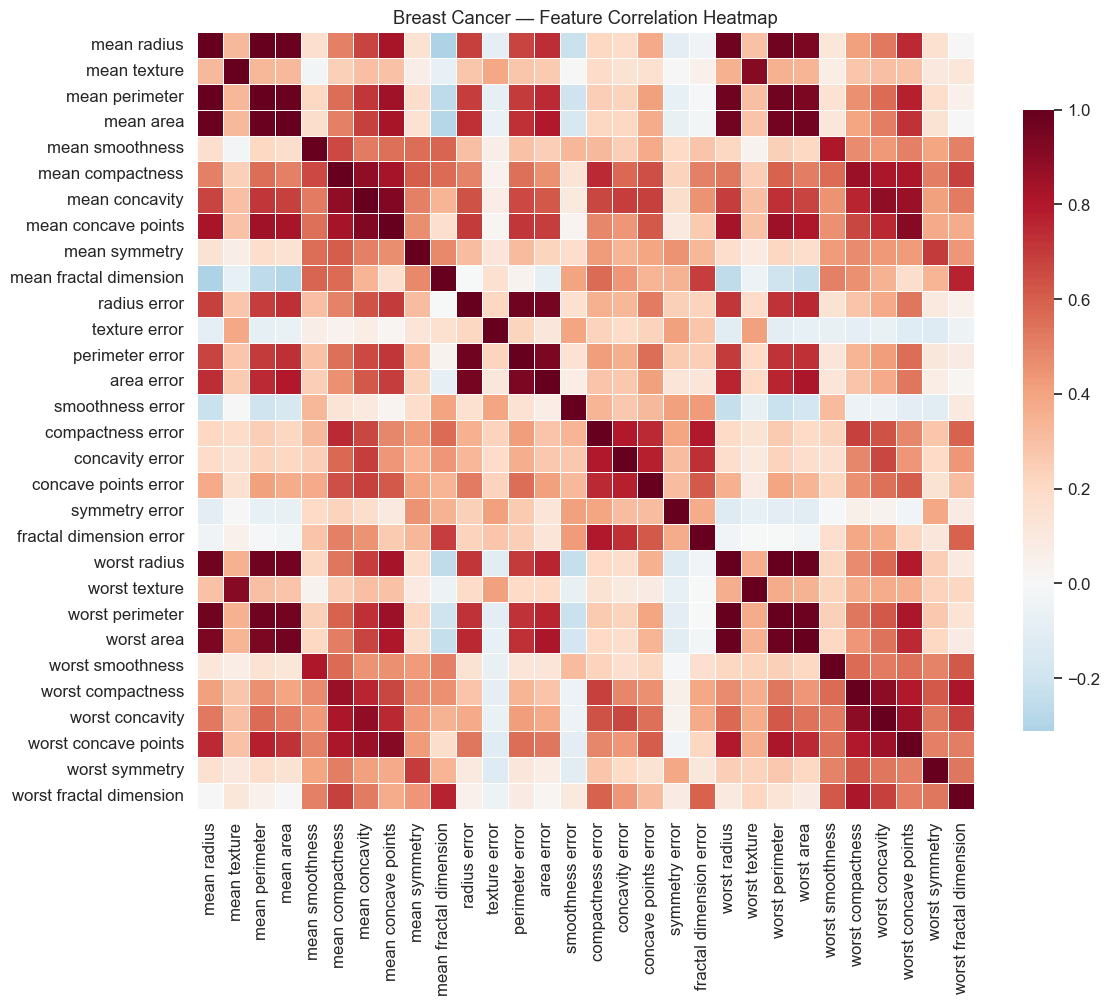

In [5]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
corr = df_bc[bc.feature_names].corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, ax=ax, 
            square=True, linewidths=0.5, 
            xticklabels=True, yticklabels=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Breast Cancer — Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_breast_cancer_corr.png', dpi=150)
plt.show()

---
## 2. Dry Bean

In [6]:
df_db = pd.read_csv('../data/dry_bean/Dry_Bean_Dataset.csv')

print(f'Shape: {df_db.shape}')
print(f'Classes: {df_db["Class"].value_counts().to_dict()}')
print(f'Missing values: {df_db.isnull().sum().sum()}')
df_db.describe().round(3)

Shape: (13611, 17)
Classes: {'DERMASON': 3546, 'SIRA': 2636, 'SEKER': 2027, 'HOROZ': 1928, 'CALI': 1630, 'BARBUNYA': 1322, 'BOMBAY': 522}
Missing values: 0


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000
mean,53048.285,855.283,320.142,202.271,1.583,0.751,53768.200,253.064,0.750,0.987,0.873,0.800,0.007,0.002,0.644,0.995
std,29324.096,214.290,85.694,44.970,0.247,0.092,29774.916,59.177,0.049,0.005,0.060,0.062,0.001,0.001,0.099,0.004
min,20420.000,524.736,183.601,122.513,1.025,0.219,20684.000,161.244,0.555,0.919,0.490,0.641,0.003,0.001,0.410,0.948
25%,36328.000,703.523,253.304,175.848,1.432,0.716,36714.500,215.068,0.719,0.986,0.832,0.762,0.006,0.001,0.581,0.994
50%,44652.000,794.941,296.883,192.432,1.551,0.764,45178.000,238.438,0.760,0.988,0.883,0.801,0.007,0.002,0.642,0.996
75%,61332.000,977.213,376.495,217.032,1.707,0.810,62294.000,279.446,0.787,0.990,0.917,0.834,0.007,0.002,0.696,0.998
max,254616.000,1985.370,738.860,460.198,2.430,0.911,263261.000,569.374,0.866,0.995,0.991,0.987,0.010,0.004,0.975,1.000


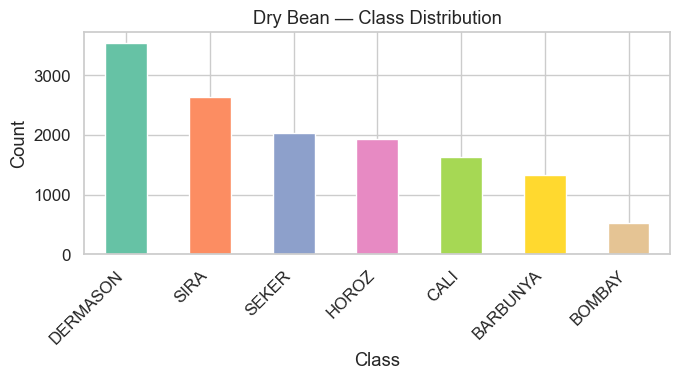

In [7]:
# Class distribution
fig, ax = plt.subplots(figsize=(7, 4))
df_db['Class'].value_counts().plot.bar(ax=ax, color=sns.color_palette('Set2', 7))
ax.set_title('Dry Bean — Class Distribution')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_dry_bean_classes.png', dpi=150)
plt.show()

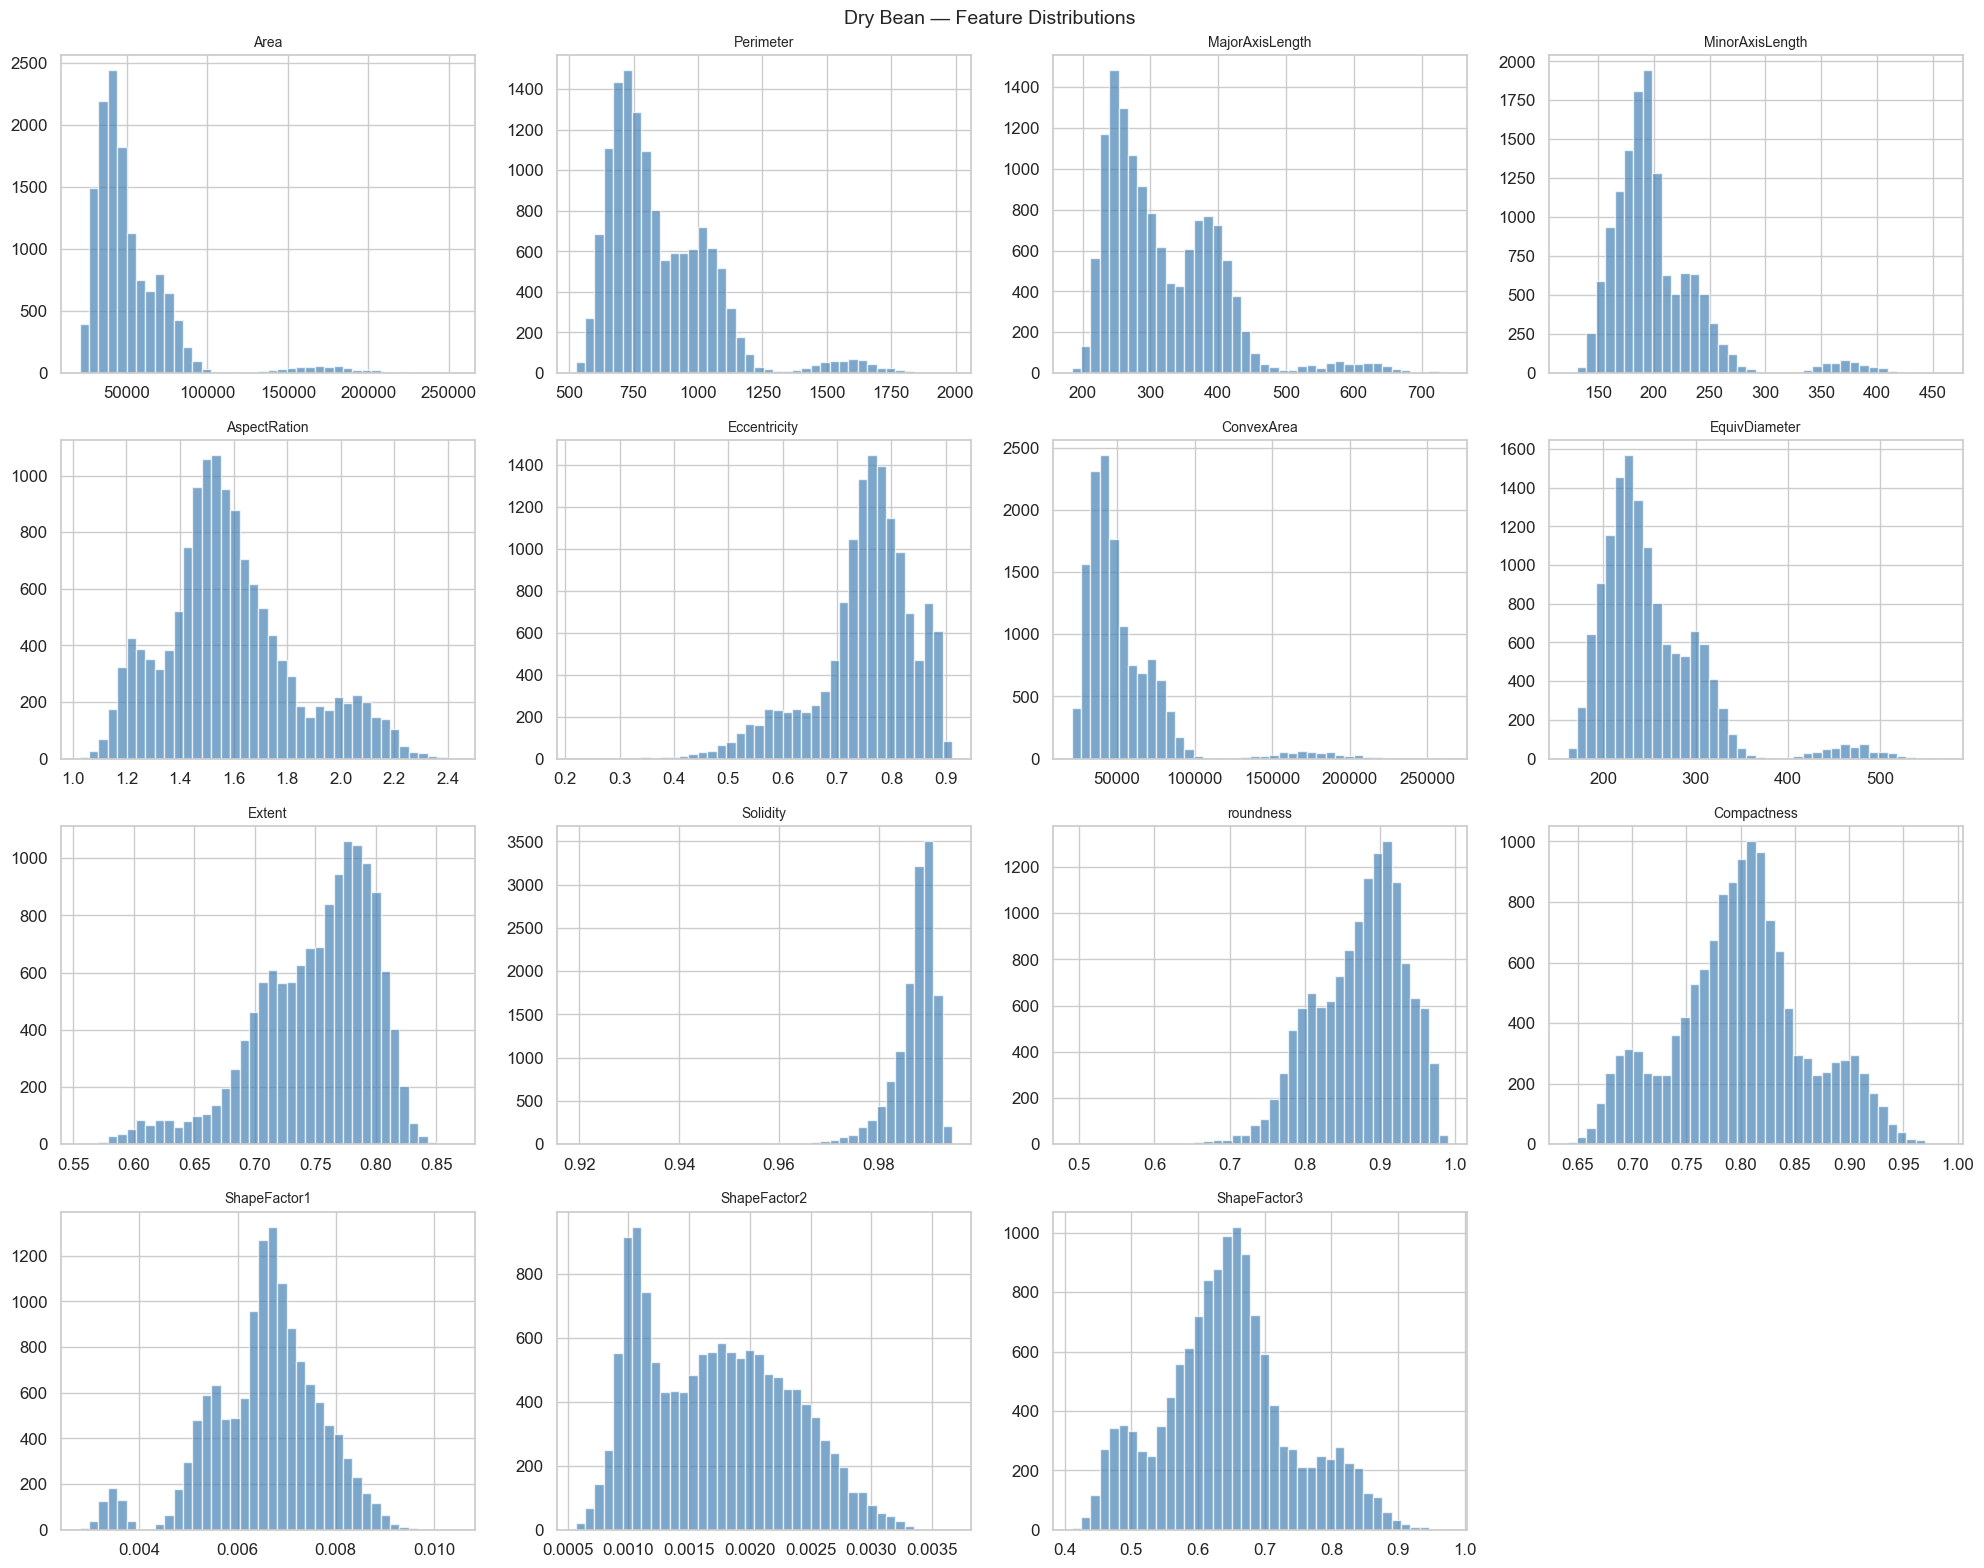

In [8]:
# Feature distributions
features = [c for c in df_db.columns if c != 'Class']
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for i, col in enumerate(features):
    ax = axes[i // 4, i % 4]
    ax.hist(df_db[col], bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(col, fontsize=10)
# Hide empty subplot
axes[3, 3].set_visible(False)
fig.suptitle('Dry Bean — Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_dry_bean_features.png', dpi=150)
plt.show()

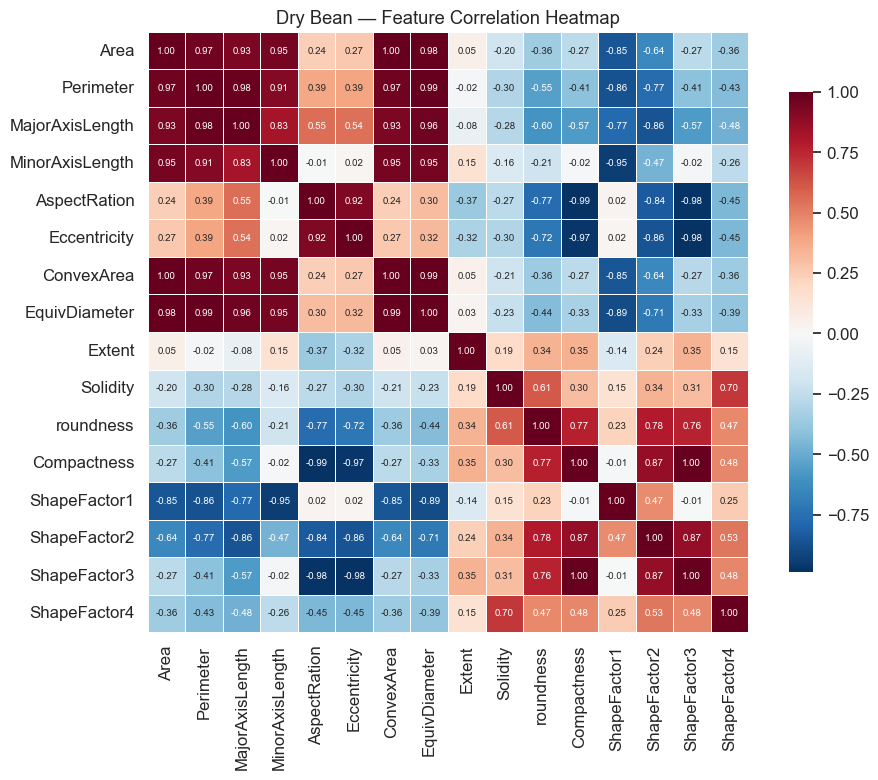

In [9]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_db[features].corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
ax.set_title('Dry Bean — Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_dry_bean_corr.png', dpi=150)
plt.show()

---
## 3. Adult Income

In [10]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]
df_ai = pd.read_csv('../data/adult_income/adult.data', header=None, names=columns, 
                     na_values=' ?', skipinitialspace=True)

print(f'Shape: {df_ai.shape}')
print(f'Classes: {df_ai["income"].value_counts().to_dict()}')
print(f'Missing values:\n{df_ai.isnull().sum()[df_ai.isnull().sum() > 0]}')

Shape: (32561, 15)
Classes: {'<=50K': 24720, '>50K': 7841}
Missing values:
Series([], dtype: int64)


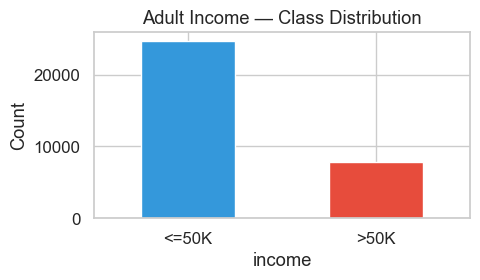

In [11]:
# Class distribution
fig, ax = plt.subplots(figsize=(5, 3))
df_ai['income'].value_counts().plot.bar(ax=ax, color=['#3498db', '#e74c3c'])
ax.set_title('Adult Income — Class Distribution')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_adult_income_classes.png', dpi=150)
plt.show()

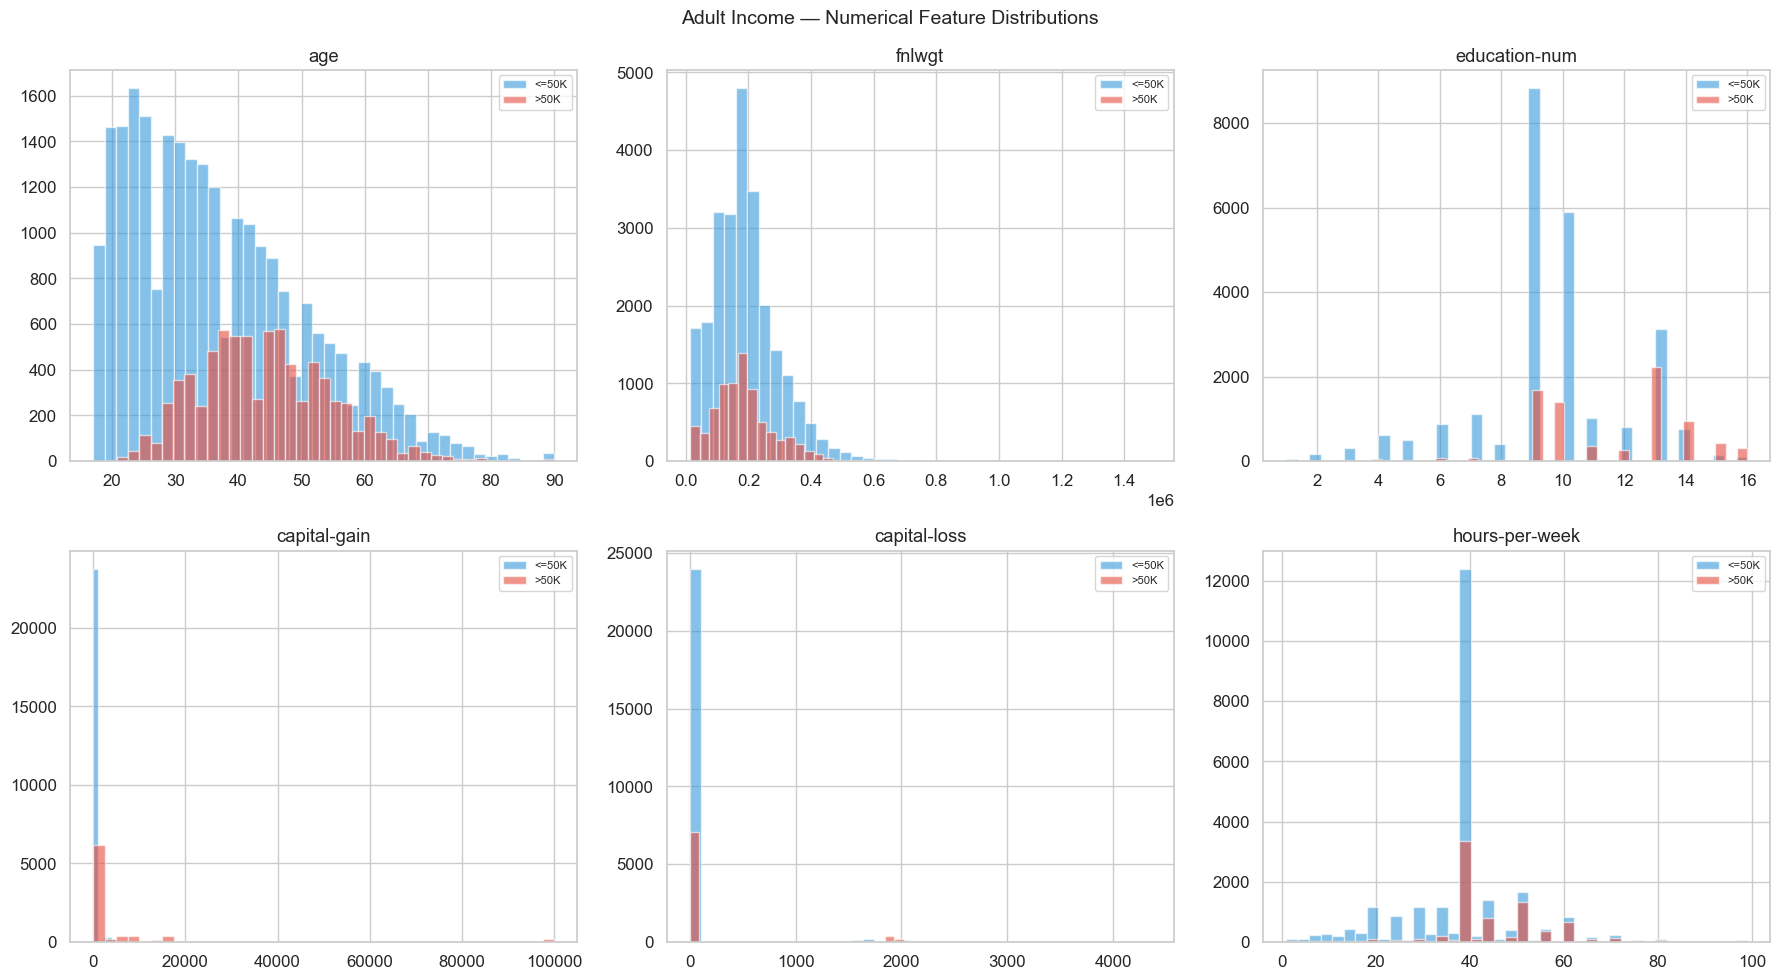

In [12]:
# Numerical feature distributions
num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(num_cols):
    ax = axes[i // 3, i % 3]
    for inc, color in zip(['<=50K', '>50K'], ['#3498db', '#e74c3c']):
        ax.hist(df_ai[df_ai['income'] == inc][col].dropna(), bins=40, 
                alpha=0.6, color=color, label=inc)
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.suptitle('Adult Income — Numerical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_adult_income_num_features.png', dpi=150)
plt.show()

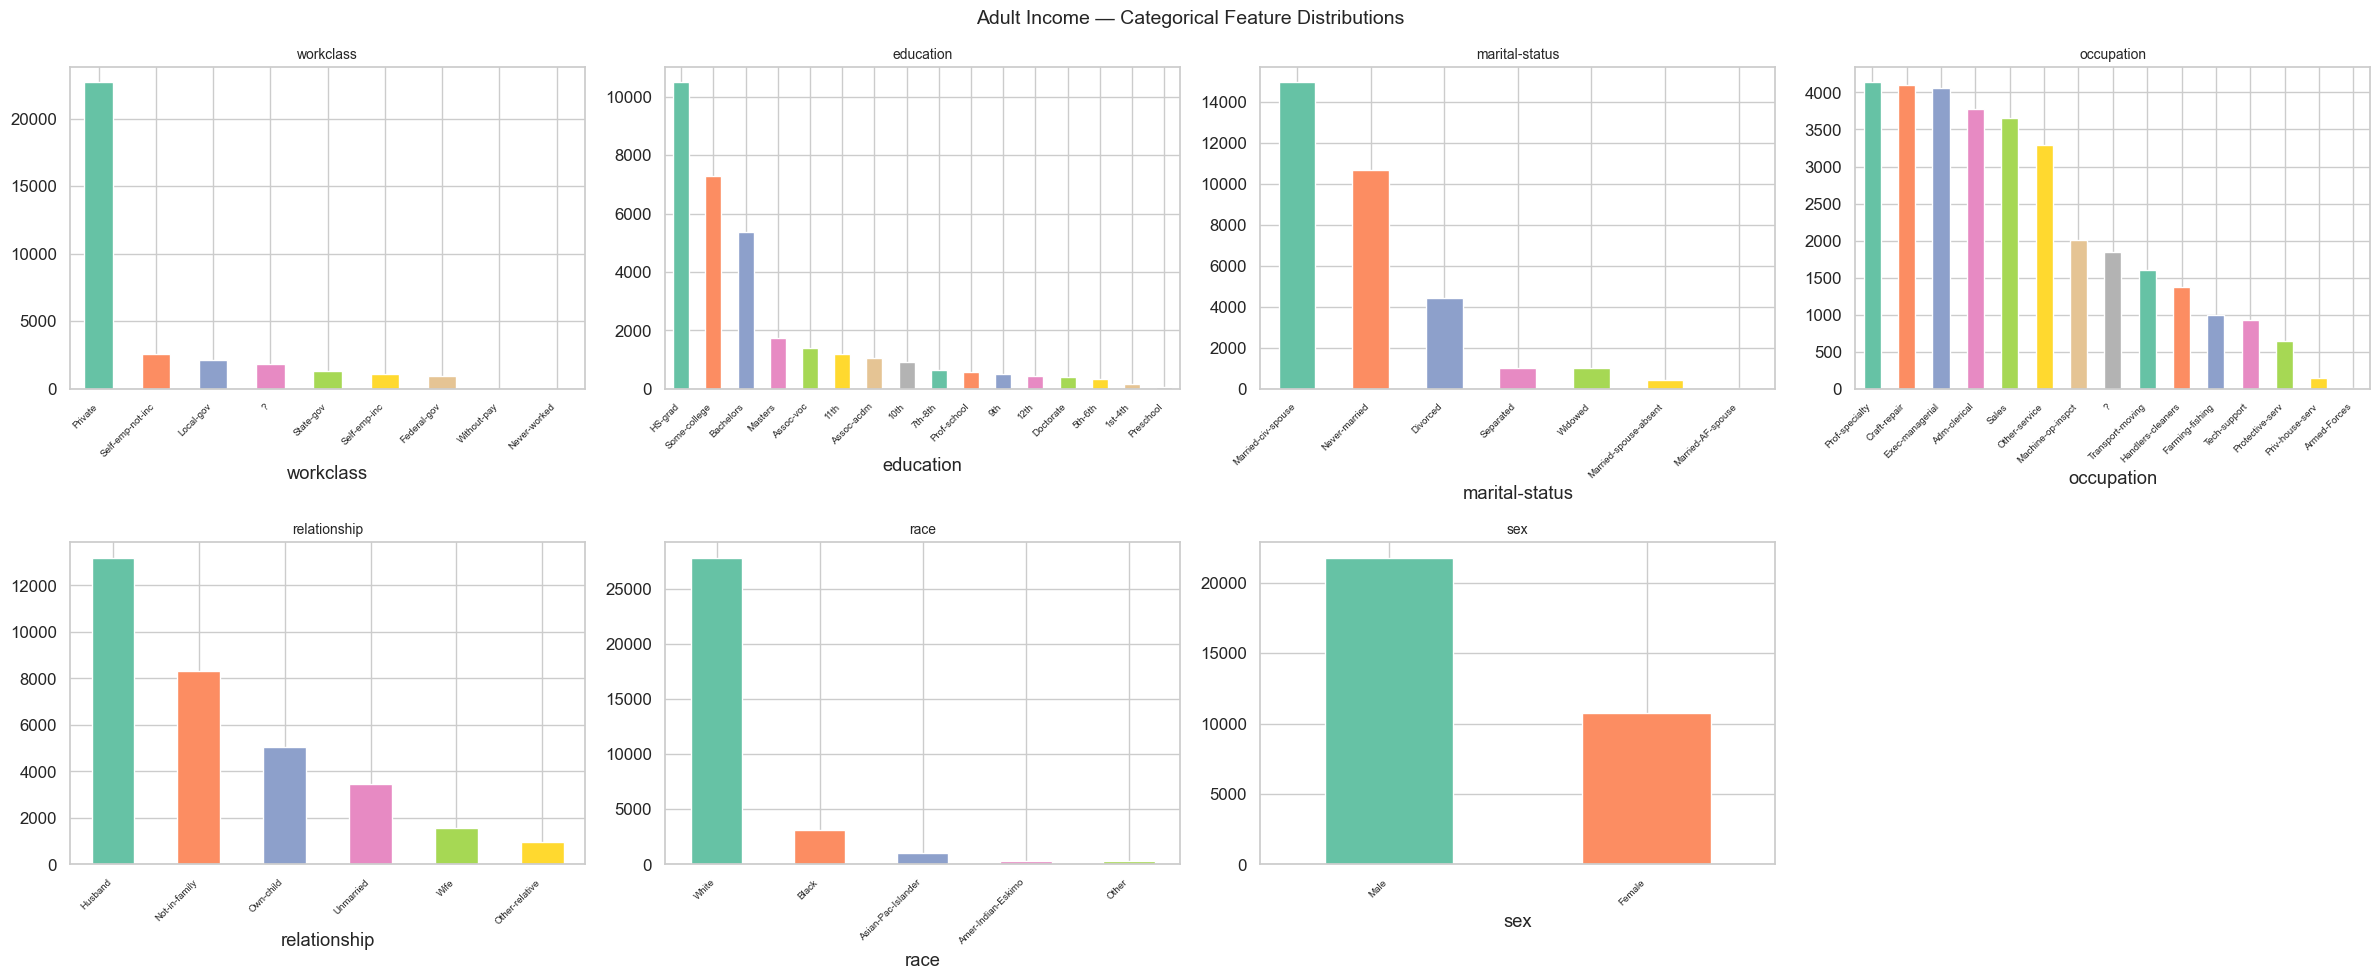

In [13]:
# Categorical features
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex']
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
for i, col in enumerate(cat_cols):
    ax = axes[i // 4, i % 4]
    df_ai[col].value_counts().plot.bar(ax=ax, color=sns.color_palette('Set2'))
    ax.set_title(col, fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
axes[1, 3].set_visible(False)
fig.suptitle('Adult Income — Categorical Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_adult_income_cat_features.png', dpi=150)
plt.show()

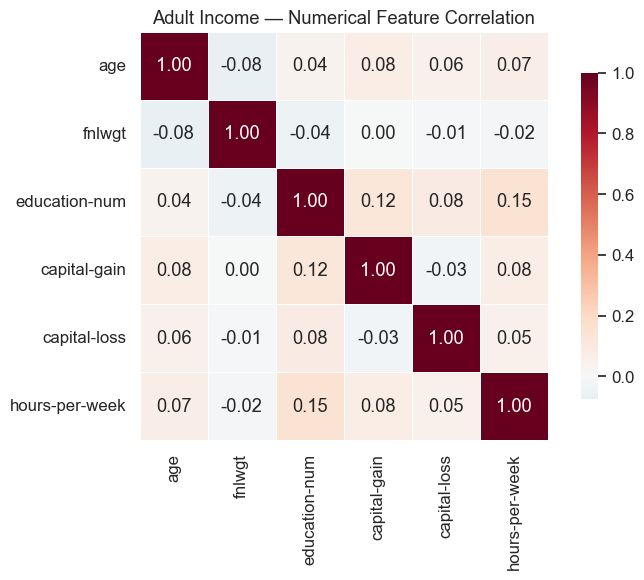

In [14]:
# Correlation heatmap (numerical features only)
fig, ax = plt.subplots(figsize=(8, 6))
corr = df_ai[num_cols].corr()
sns.heatmap(corr, cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5,
            annot=True, fmt='.2f',
            cbar_kws={'shrink': 0.8})
ax.set_title('Adult Income — Numerical Feature Correlation')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eda_adult_income_corr.png', dpi=150)
plt.show()

---
## Summary Comparison

In [15]:
summary = pd.DataFrame({
    'Dataset': ['Breast Cancer', 'Dry Bean', 'Adult Income'],
    'Samples': [569, 13611, 48842],
    'Features': [30, 16, '108 (after one-hot)'],
    'Classes': [2, 7, 2],
    'Class Balance': [
        '357 benign / 212 malignant',
        'Imbalanced (3546 DERMASON vs 522 BOMBAY)',
        '37155 <=50K / 11687 >50K'
    ],
    'Missing Values': ['None', 'None', 'None (dropped)'],
    'Feature Types': ['All numerical', 'All numerical', 'Mixed (6 categorical + 8 numerical)']
})
summary

,Dataset,Samples,Features,Classes,Class Balance,Missing Values,Feature Types
0,Breast Cancer,569,30,2,357 benign / 212 malignant,None,All numerical
1,Dry Bean,13611,16,7,Imbalanced (3546 DERMASON vs 522 BOMBAY),None,All numerical
2,Adult Income,48842,108 (after one-hot),2,37155 <=50K / 11687 >50K,None (dropped),Mixed (6 categorical + 8 numerical)
